In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
from sklearn.decomposition import FastICA
import scipy.io as sio

# ======================== НАСТРОЙКИ ========================
np.random.seed(42)
N_CHANNELS = 10
N_TIMEPOINTS = 500
TIME_AXIS = np.arange(N_TIMEPOINTS)
AMP_1, FREQ_1 = 2.0, 0.05
AMP_2, FREQ_2 = 1.0, 0.10
PLOT_LIMIT = 100
VERT_OFFSET = 2.5

# Истинные паттерны (не менять)
spatial_1 = np.sin(np.linspace(0, 2*np.pi, N_CHANNELS))
spatial_2 = np.cos(np.linspace(0, 2*np.pi, N_CHANNELS))
temporal_1 = AMP_1 * np.sin(2*np.pi*FREQ_1*TIME_AXIS)
temporal_2 = AMP_2 * np.sin(2*np.pi*FREQ_2*TIME_AXIS)

# def generate_data(noise_level):
#     clean = np.outer(spatial_1, temporal_1) + np.outer(spatial_2, temporal_2)
#     noise = np.random.randn(N_CHANNELS, N_TIMEPOINTS) * noise_level
#     return clean + noise, clean, noise

def generate_data(noise_level):
    clean = np.outer(spatial_1, temporal_1) + np.outer(spatial_2, temporal_2)
    
    # 1. Генерируем независимый шум
    base_noise = np.random.randn(N_CHANNELS, N_TIMEPOINTS) * noise_level
    
    # 2. Создаем структуру шума (коррелируем каналы между собой)
    rng = np.random.RandomState(99) 
    noise_mixing_matrix = rng.randn(N_CHANNELS, N_CHANNELS)
    
    # Умножаем независимый шум на матрицу, делая его структурным
    structured_noise = noise_mixing_matrix @ base_noise 
    
    return clean + structured_noise, clean, structured_noise

def normalize_component(weights, temporal_pc, ref_signal=None, target_amp=None):
    scale = np.max(np.abs(weights))
    w_norm, t_norm = weights/scale, temporal_pc*scale
    if ref_signal is not None:
        if np.corrcoef(t_norm, ref_signal)[0,1] < 0:
            w_norm, t_norm = -w_norm, -t_norm
    if target_amp is not None and np.max(np.abs(t_norm)) > 0:
        t_norm = t_norm / np.max(np.abs(t_norm)) * target_amp
    return w_norm, t_norm

def plot_results(noisy_data, components, spatial_weights, titles, eigenvalues=None, plot_limit=100):
    # --- 1. Исходные данные ---
    n_chan = noisy_data.shape[0]
    fig, ax = plt.subplots(figsize=(8, 3))
    for ch in range(min(10, n_chan)): # Изменил на 10, чтобы видеть все каналы
        ax.plot(TIME_AXIS[:plot_limit], noisy_data[ch, :plot_limit] + ch * VERT_OFFSET, lw=0.8, alpha=0.7)
    ax.set_xlabel('Время'); ax.set_ylabel('Канал'); ax.set_title('Исходные данные'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # --- Матрица корреляций и График собственных значений ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Матрица корреляций
    corr_matrix = np.corrcoef(noisy_data)
    im = ax1.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax1)
    ax1.set_title('Корреляция каналов')
    ax1.set_xlabel('Каналы'); ax1.set_ylabel('Каналы')

    # График собственных значений (Scree Plot)
    if eigenvalues is not None:
        ax2.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', color='tab:red', ms=4)
        ax2.set_title('Собственные значения (Scree Plot)')
        ax2.set_xlabel('Номер компоненты')
        ax2.set_ylabel('Значение')
        ax2.grid(alpha=0.3)
    
    plt.tight_layout(); plt.show()

    # --- 3. Пространственные паттерны  ---
    fig, ax = plt.subplots(figsize=(6, 4))
    for w, lbl in zip(spatial_weights[:3], titles[:3]):
        ax.plot(np.arange(len(w)), w, marker='o', ms=3, label=lbl)
    ax.set_xlabel('Канал'); ax.set_ylabel('Вес'); ax.set_title('Пространственные паттерны'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # --- 4. Временные компоненты  ---
    fig, ax = plt.subplots(figsize=(8, 4))
    for t, lbl in zip(components[:3], titles[:3]):
        ax.plot(TIME_AXIS[:plot_limit], t[:plot_limit], label=lbl, lw=1.5)
    ax.plot(TIME_AXIS[:plot_limit], temporal_1[:plot_limit], 'k--', label='Источник 1', alpha=0.7)
    ax.plot(TIME_AXIS[:plot_limit], temporal_2[:plot_limit], 'r--', label='Источник 2', alpha=0.7)
    ax.set_xlabel('Время'); ax.set_ylabel('Амплитуда'); ax.set_title('Временные компоненты'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()



=== ЗАДАНИЕ 1: PCA ===


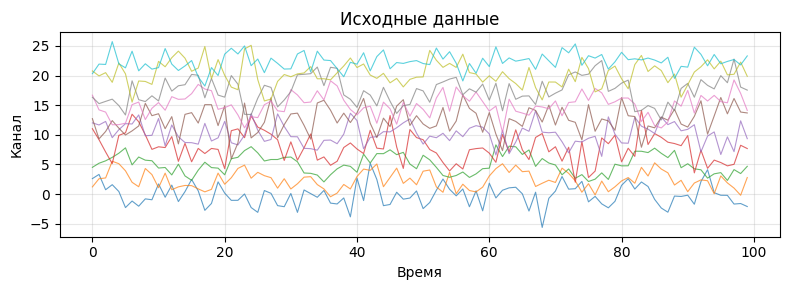

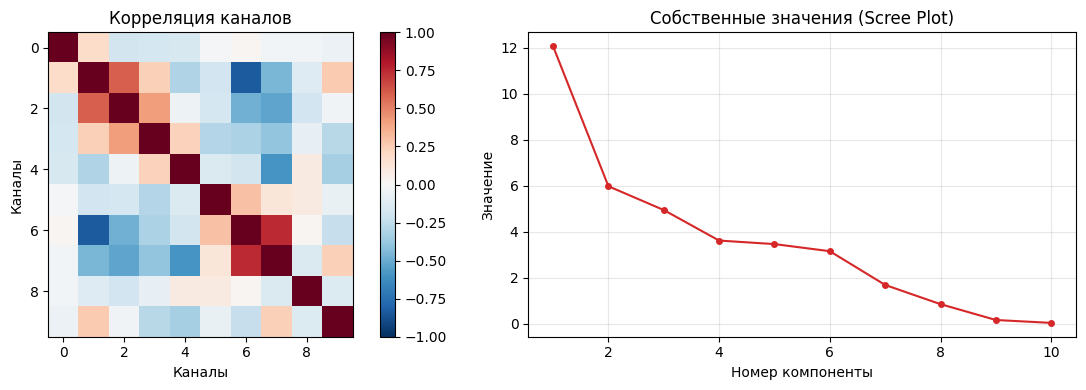

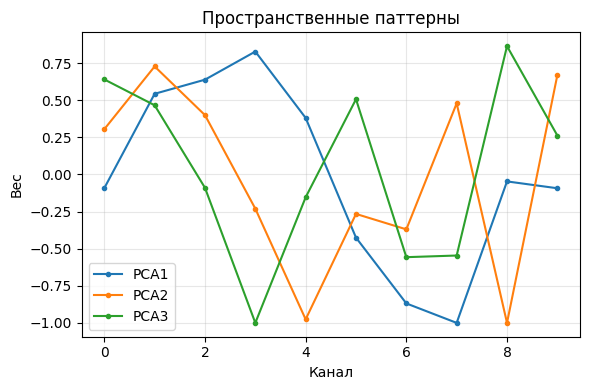

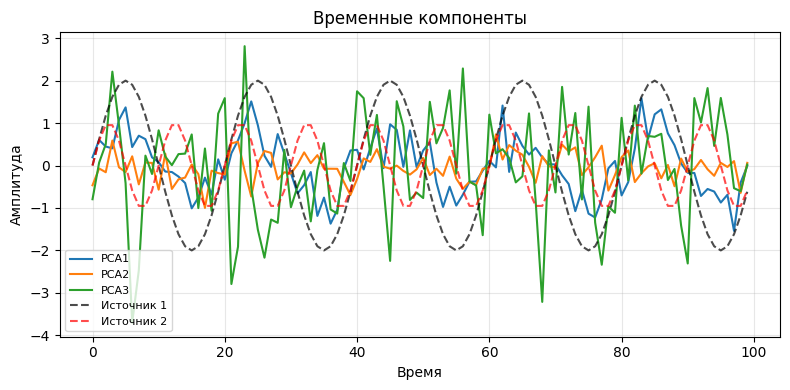

PCA: corr1 = 0.7911, corr2 = 0.3307


In [2]:
# ======================== ЗАДАНИЕ 1: PCA ========================
print("\n=== ЗАДАНИЕ 1: PCA ===")
NOISE_1 = 0.5 
noisy_1, clean_1, noise_1 = generate_data(NOISE_1)

# Центрирование
data_centered_1 = noisy_1 - np.mean(noisy_1, axis=1, keepdims=True)

# Ковариационная матрица
cov_matrix_1 = np.cov(data_centered_1)

# Собственные значения и векторы
eigenvalues_1, eigenvectors_1 = np.linalg.eigh(cov_matrix_1)

# Сортировка по убыванию
sorted_idx_1 = np.argsort(eigenvalues_1)[::-1]
eigenvalues_1 = eigenvalues_1[sorted_idx_1]
eigenvectors_1 = eigenvectors_1[:, sorted_idx_1]

# Проекция на компоненты
principal_components_1 = eigenvectors_1.T @ data_centered_1

# Визуализация
w1, t1 = normalize_component(eigenvectors_1[:,0], principal_components_1[0], temporal_1, AMP_1)
w2, t2 = normalize_component(eigenvectors_1[:,1], principal_components_1[1], temporal_2, AMP_2)
w3, t3 = normalize_component(eigenvectors_1[:,2], principal_components_1[2])

plot_results(noisy_1, [t1, t2, t3], [w1, w2, w3], ['PCA1', 'PCA2', 'PCA3'], eigenvalues=eigenvalues_1)

corr1_pca = np.abs(np.corrcoef(t1, temporal_1)[0,1])
corr2_pca = np.abs(np.corrcoef(t2, temporal_2)[0,1])
print(f"PCA: corr1 = {corr1_pca:.4f}, corr2 = {corr2_pca:.4f}")



=== ЗАДАНИЕ 2: GED ===


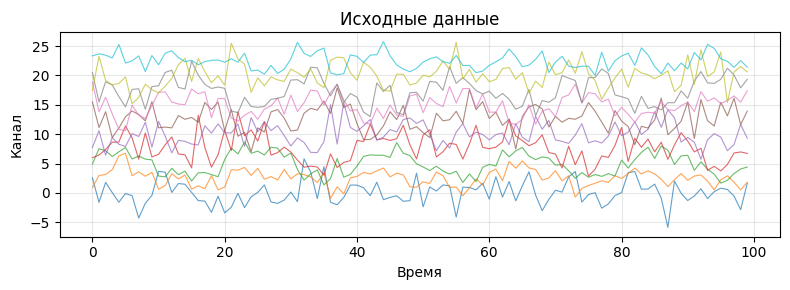

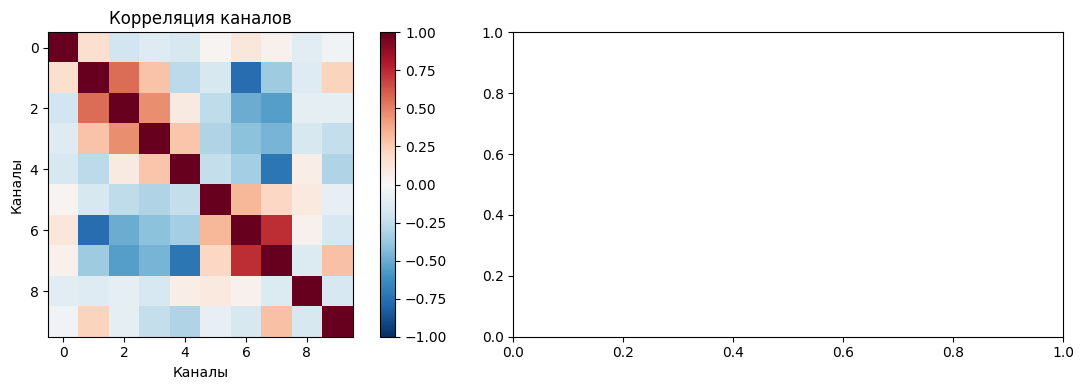

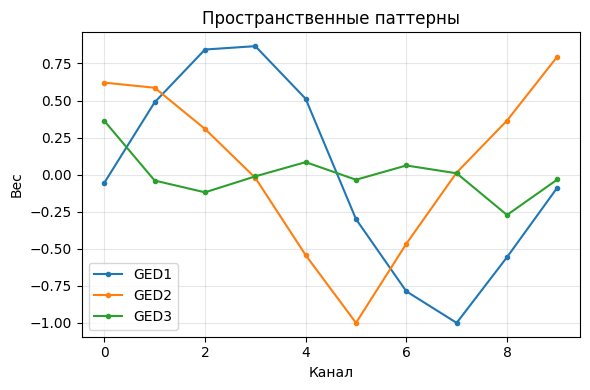

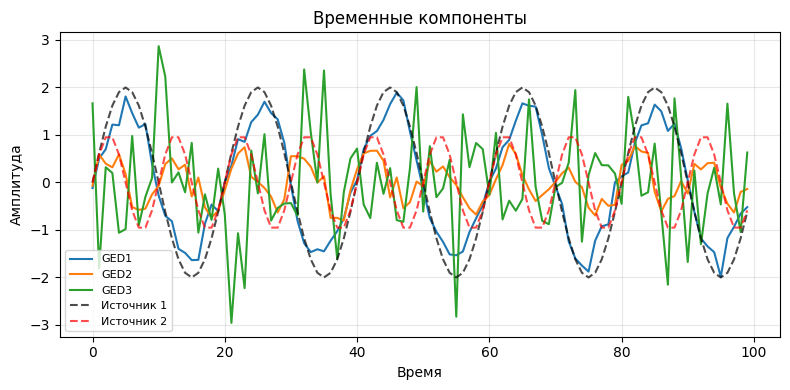

PCA: corr1 = 0.7911, corr2 = 0.3307
GED: corr1 = 0.9811, corr2 = 0.8318


In [3]:
# ======================== ЗАДАНИЕ 2: GED ========================
print("\n=== ЗАДАНИЕ 2: GED ===")
NOISE_2 = 0.5  
noisy_2, clean_2, noise_2 = generate_data(NOISE_2)

data_c_2 = noisy_2 - noisy_2.mean(axis=1, keepdims=True)
noise_c_2 = noise_2 - noise_2.mean(axis=1, keepdims=True)

# Ковариации
cov_sig_2 = np.cov(data_c_2)
cov_noise_2 = np.cov(noise_c_2)

# Регуляризация
reg = 1e-8 * np.trace(cov_noise_2) / N_CHANNELS
cov_noise_reg_2 = cov_noise_2 + reg * np.eye(N_CHANNELS)

# GED
evals_2, evecs_2 = scipy.linalg.eigh(cov_sig_2, cov_noise_reg_2)

# Сортировка
idx_ged = np.argsort(evals_2)[::-1]
evals_2 = evals_2[idx_ged]
evecs_2 = evecs_2[:, idx_ged]
comp_ts_2 = evecs_2.T @ data_c_2

# Форвард-модель (пространственный паттерн)
# def compute_forward(w, C_sig, C_noise):
#     denom = w.T @ C_noise @ w
#     return (C_sig @ w) / denom if np.abs(denom) > 1e-12 else np.zeros_like(w)

def compute_forward(w, C_sig, C_noise):
    denom = w.T @ C_noise @ w
    if np.abs(denom) < 1e-12:
        return np.zeros_like(w)
    return (C_sig @ w) / denom

C_sig_diff_2 = cov_sig_2 - cov_noise_2
f1 = compute_forward(evecs_2[:,0], C_sig_diff_2, cov_noise_reg_2)
f2 = compute_forward(evecs_2[:,1], C_sig_diff_2, cov_noise_reg_2)

w1g, t1g = normalize_component(f1, comp_ts_2[0], temporal_1, AMP_1)
w2g, t2g = normalize_component(f2, comp_ts_2[1], temporal_2, AMP_2)
# plot_results(noisy_2, [t1g,t2g,comp_ts_2[2]], [w1g,w2g,evecs_2[:,2]], ['GED1','GED2','GED3'])

plot_results(noisy_2, [t1g,t2g,comp_ts_2[2]], [w1g,w2g,evecs_2[:,2]], ['GED1','GED2','GED3'])

corr1_ged = np.abs(np.corrcoef(t1g, temporal_1)[0,1])
corr2_ged = np.abs(np.corrcoef(t2g, temporal_2)[0,1])
print(f"PCA: corr1 = {corr1_pca:.4f}, corr2 = {corr2_pca:.4f}")
print(f"GED: corr1 = {corr1_ged:.4f}, corr2 = {corr2_ged:.4f}")


Чтобы GED выиграл у PCA, шум должен быть пространственно коррелированным (или «структурированным»).

### Алгоритм GED:

1. Данные центрируем (вычитая среднее по времени), дисперсию к едингице не преиводим! (это исказит физический смысл, получаемый с датчиков)
2. Берём матрицы шума и сигнала.
Матрица шума ($C_{noise}$):$$C_{noise} = \begin{pmatrix} 2 & 1 & 0 & 0 & 0 \\ 1 & 2 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 0 & 1 \end{pmatrix}$$Что это значит? На каналах 1 и 2 есть шум. Их индивидуальная дисперсия равна 2, и они положительно коррелируют между собой (ковариация = 1). То есть шум бьет по обоим каналам одновременно в одном направлении.Матрица сигнала ($C_{signal}$):$$C_{signal} = \begin{pmatrix} 6 & -3 & 0 & 0 & 0 \\ -3 & 6 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 0 & 1 \end{pmatrix}$$ Что это значит? Когда включился полезный сигнал, дисперсия на каналах 1 и 2 выросла до 6, но их взаимосвязь стала отрицательной (-3). Это значит, что полезный источник качает эти каналы в противофазе (на одном канале плюс, на другом — минус).

Шаг алгоритма GED:Мы ищем такой вектор весов $\mathbf{w}$, который решит уравнение:$$\det(C_{signal} - \lambda C_{noise}) = 0$$Где $\lambda$ — это и есть наше отношение сигнал/шум (SNR), которое мы максимизируем.

Подставим наши числа для блока 1-го и 2-го каналов:$$\det \begin{pmatrix} 6 - 2\lambda & -3 - \lambda \\ -3 - \lambda & 6 - 2\lambda \end{pmatrix} = 0$$

Отсюда получаем два собственных значения (два SNR):

* $\lambda_1 = 9$ (Отношение сигнал/шум равно 9!)

* $\lambda_2 = 1$ (Сигнал равен шуму)

Ищем пространственный фильтр $\mathbf{w}$ для максимального $\lambda = 9$:Подставляем $\lambda = 9$ обратно в уравнение матрицы:$$\begin{pmatrix} 6 - 18 & -3 - 9 \\ -3 - 9 & 6 - 18 \end{pmatrix} \mathbf{w} = \begin{pmatrix} -12 & -12 \\ -12 & -12 \end{pmatrix} \begin{pmatrix} w_1 \\ w_2 \end{pmatrix} = 0$$Это дает нам простейшее уравнение: $-12w_1 - 12w_2 = 0 \implies w_1 = -w_2$.

Базовый вектор: $\mathbf{w} = [1, -1, 0, 0, 0]^T$.

Вектор $\mathbf{w}$ применяется ко всем каналам сразу с помощью обычного линейного взвешенного суммирования (матричного умножения).Если у нас есть матрица зашумленных данных $X$ размером $5 \times 1000$ (5 каналов, 1000 точек) и мы нашли вектор весов для первой компоненты $\mathbf{w}_1 = [1, -1, 0, 0, 0]^T$ (размером $5 \times 1$), то чистый временной ряд этой компоненты $y_1(t)$ вычисляется как:$$y_1(t) = \mathbf{w}_1^T X$$

То есть вектор $\mathbf{w}$ работает как пространственный фильтр. Он «схлопывает» 5 реальных физических каналов в 1 новый «виртуальный» канал (компоненту), в котором шум уничтожен за счет вычитания каналов друг из друга.Если мы возьмем несколько векторов $\mathbf{w}$ (например, для двух наибольших собственных значений) и соберем их в матрицу $W = [\mathbf{w}_1, \mathbf{w}_2]$, то получим сразу два очищенных источника: $Y = W^T X$.



### Матрица простого шума
$$C_{noise\_sample} = \begin{pmatrix} 2.10 & 0.90 & 0.15 & -0.10 & 0.05 \\ 0.90 & 1.90 & -0.05 & 0.08 & -0.12 \\ 0.15 & -0.05 & 1.05 & -0.03 & 0.04 \\ -0.10 & 0.08 & -0.03 & 0.95 & 0.02 \\ 0.05 & -0.12 & 0.04 & 0.02 & 1.02 \end{pmatrix}$$





=== ЗАДАНИЕ 3: ICA ===


d:\code\DPoS\.venv\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


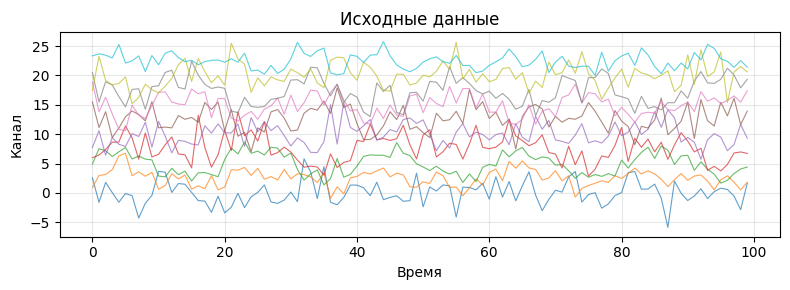

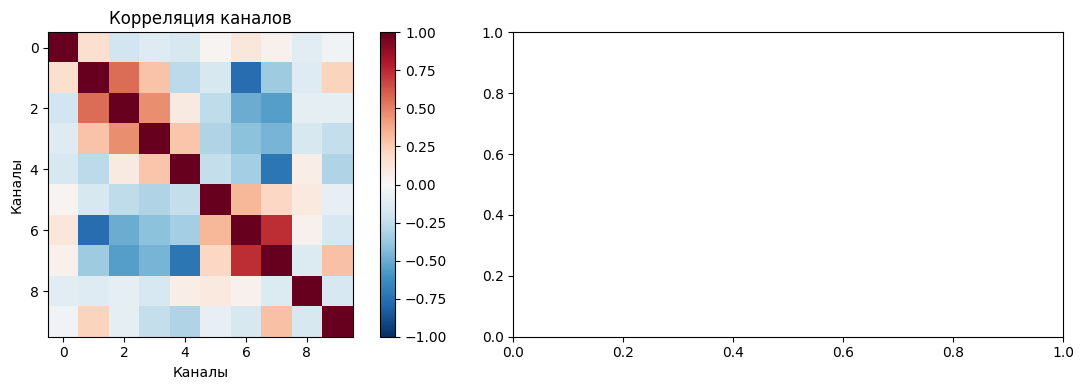

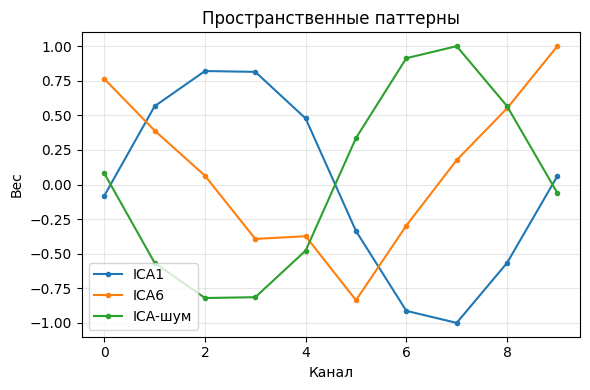

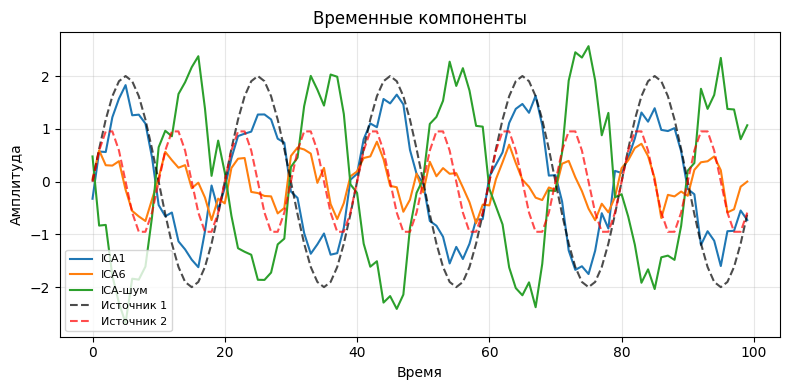

PCA: corr1 = 0.7911, corr2 = 0.3307
GED: corr1 = 0.9811, corr2 = 0.8318
ICA: corr1 = 0.9727, corr2 = 0.7883


In [4]:
# ======================== ЗАДАНИЕ 3: ICA ========================
print("\n=== ЗАДАНИЕ 3: ICA ===")
X_ica_input = noisy_2 - noisy_2.mean(axis=1, keepdims=True)
X_ica = X_ica_input.T 

# FastICA
ica = FastICA(n_components=N_CHANNELS, random_state=42, whiten='arbitrary-variance')
sources = ica.fit_transform(X_ica).T  # Транспонируем в (компоненты, время)
spatial_maps = ica.mixing_.T

# Сортировка по энергии
energy = np.sum(spatial_maps**2, axis=1)
sorted_idx = np.argsort(energy)[::-1]
spatial_maps = spatial_maps[sorted_idx]
sources = sources[sorted_idx]

# Поиск соответствия компонентам (максимальная корреляция)
corrs1 = [np.abs(np.corrcoef(s, temporal_1)[0,1]) for s in sources]
corrs2 = [np.abs(np.corrcoef(s, temporal_2)[0,1]) for s in sources]
idx1, idx2 = np.argmax(corrs1), np.argmax(corrs2)

# ИСПРАВЛЕНИЕ 1: Правильный порядок w (пространство) и t (время)
w1i, t1i = normalize_component(spatial_maps[idx1], sources[idx1], temporal_1, AMP_1)
w2i, t2i = normalize_component(spatial_maps[idx2], sources[idx2], temporal_2, AMP_2)

# ИСПРАВЛЕНИЕ 2: Нормализуем также и шумовую компоненту для корректного отображения масштаба
w3i, t3i = normalize_component(spatial_maps[0], sources[0])

# Передаем правильные t и w
plot_results(noisy_2, [t1i, t2i, t3i], 
             [w1i, w2i, w3i], [f'ICA{idx1+1}', f'ICA{idx2+1}', 'ICA-шум'])

corr1_ica = np.abs(np.corrcoef(t1i, temporal_1)[0,1])
corr2_ica = np.abs(np.corrcoef(t2i, temporal_2)[0,1])
print(f"PCA: corr1 = {corr1_pca:.4f}, corr2 = {corr2_pca:.4f}")
print(f"GED: corr1 = {corr1_ged:.4f}, corr2 = {corr2_ged:.4f}")
print(f"ICA: corr1 = {corr1_ica:.4f}, corr2 = {corr2_ica:.4f}")

### Алгоритм ICA
### 1. «Отбеливание» (Whitening). Для n каналов нам нужно сделать так, чтобы они одновременно имели дисперсию = 1 и не коррелировали между собой (матрица ковариации должна стать идеально единичной $I$).

Делается это с помощью PCA:
1. Считаем ковариационную матрицу данных $C$. 
2. Делаем её собственное разложение: $C = E D E^T$, где $E$ — матрица собственных векторов (поворот), а $D$ — диагональная матрица собственных значений (дисперсии вдоль новых осей).
3. Матрица отбеливания считается как: $W_{white} = D^{-1/2} E^T$.
4. Умножаем её на данные: $X_{white} = W_{white} X$.

Что произошло геометрически? Операция $E^T X$ повернула наше облако точек так, что оси стали некоррелированными (это стандартный PCA). А умножение на $D^{-1/2}$ сжало или растянуло облако по каждой из этих осей, превратив вытянутый «эллипс» данных в идеальный круг (сферу), где дисперсия в любом направлении равна 1.

### 2. Истинные независимые сигналы (которые мы хотим найти)

Пусть идеальные скрытые данные — это бинарные сигналы (например, прямоугольные импульсы):$s_1 = [1, -1, 1, -1]$$s_2 = [1, 1, -1, -1]$

Посчитаем математическую негауссовость (эксцесс/куртозис) для сигнала $s_1$. Формула эксцесса при среднем = 0 и дисперсии = 1: 

$K = E[s^4] - 3$.

Возводим точки в 4-ю степень: $1^4 = 1, (-1)^4 = 1 \dots$ 

Все четвертые степени равны 1. Среднее четвертых степеней: $E[s_1^4] = (1 + 1 + 1 + 1) / 4 = 1$. Эксцесс: $K(s_1) = 1 - 3 = \mathbf{-2}$. (Это сильное отличие от Гауссианы, у которой эксцесс равен 0).

### 3: Реальные сигналы

Мы не видим $s_1$ и $s_2$. Они смешались в пространстве, например, повернувшись на 45 градусов друг относительно друга. Прибор записал смесь $x_1$:$$x_1 = \frac{1}{\sqrt{2}}s_1 + \frac{1}{\sqrt{2}}s_2 \approx 0.707 \cdot s_1 + 0.707 \cdot s_2$$

Давай посчитаем значения этой смеси $x_1$ в наших 4 точках времени:

* Точка 1: $0.707(1) + 0.707(1) = 1.414$
* Точка 2: $0.707(-1) + 0.707(1) = 0$
* Точка 3: $0.707(1) + 0.707(-1) = 0$...
* в итоге получаем вектор смеси: $x_1 = [1.414, 0, 0, -1.414]$

### 4 Как ICA находит решение?
ICA начинает крутить оси координат (создаётся случайный вектор w) и мерить эксцесс получающейся проекции. Посчитаем эксцесс для этой смеси $x_1$:
* Дисперсия смеси осталась равной 1 ( $(1.414^2 + 0 + 0 + (-1.414)^2)/4 = (2 + 2)/4 = 1$ ).
* Возводим точки смеси в 4-ю степень: $1.414^4 = 4$, $0^4 = 0$, $(-1.414)^4 = 4$.
* Среднее четвертых степеней: $E[x_1^4] = (4 + 0 + 0 + 4) / 4 = 2$.
* Вычисляем эксцесс смеси: $K(x_1) = 2 - 3 = \mathbf{-1}$.

### 5 Финал работы ICA 
Эксцесс чистого источника = $\mathbf{-2}$

Эксцесс смеси = $\mathbf{-1}$ 

(он стал ближе к 0, то есть смесь стала более «гауссовской», распределение стало более гладким из-за появления нулей).Алгоритм FastICA берет смесь $x_1$ (у которой эксцесс $-1$), начинает математически «вращать» её систему координат в 5-мерном пространстве и видит, что при определенном угле поворота эксцесс начинает уходить от нуля и падает до $-2$.Как только алгоритм нащупал точку, где абсолютное значение эксцесса стало максимально возможным (в нашем случае $|-2|$), он останавливается.

Таким образом находим первый вектор w1

Затем начинается поиск следующей компоненты ($\mathbf{w}_2$). Алгоритм снова инициализирует случайный вектор для $\mathbf{w}_2$, начинает его итеративно двигать, но после каждого микрошага он принудительно «вычитает» из него всё, что совпадает с уже найденным вектором $\mathbf{w}_1$ (метод граммовской ортогонализации). 

Это нужно, чтобы $\mathbf{w}_2$ не сошелся к тому же самому источнику, что и первый.

Когда ICA нашел все 5 векторов, он собирает их по строкам в одну общую матрицу десмешивания (unmixing matrix) $W$ размера $5 \times 5$.Геометрически в отбеленном пространстве (где данные уже превращены в идеальный круг) эта матрица является матрицей чистого поворота (ортогональной матрицей). Она просто поворачивает этот круг вокруг центра координат на определенный угол. На выходе ты получаешь матрицу $S$ размером $5 \times 1000$, где каждая строка — это чистый временной ряд одного из 5 независимых источников (синусоида 1, синусоида 2, моргание глаза и т.д.).


### Вопрос из лабораторной:

Первый шаг ICA — отбеливание. Мы принудительно сделали дисперсию всех каналов равной 1. Для алгоритма ICA огромный артефакт от моргания (который в реальности в 100 раз сильнее сигналов мозга) и крошечная полезная синусоида на заднем плане имеют совершенно одинаковую дисперсию. ICA ищет только независимость и негауссовость.

Поскольку поиск начинается со случайных векторов (random seed), то, какую компоненту алгоритм «нащупает» и выведет первой, зависит исключительно от везения и начальной инициализации. Если поменять random_state в коде, FastICA выдаст те же самые источники, но поменяет их местами (например, то, что было Компонентой 1, станет Компонентой 4).

Как это влияет на интерпретацию?

Нельзя доверять номерам: Нельзя просто сказать: «Я возьму первые две компоненты ICA, потому что они самые важные». Компонента №1 может оказаться шумом сети 50 Гц, а полезный сигнал будет лежать под номером 5.

Необходимость ручного или экспертного отбора: Чтобы интерпретировать результаты ICA, нужно посмотреть на все компоненты без исключения. Ты должен построить для каждой компоненты:

* Её временной ход (чтобы увидеть паттерн).

* Её спектр мощности (синусоида даст четкий пик на своей частоте).

* Её пространственную карту / топографию (topoplot), чтобы понять, где в пространстве сидит этот источник.

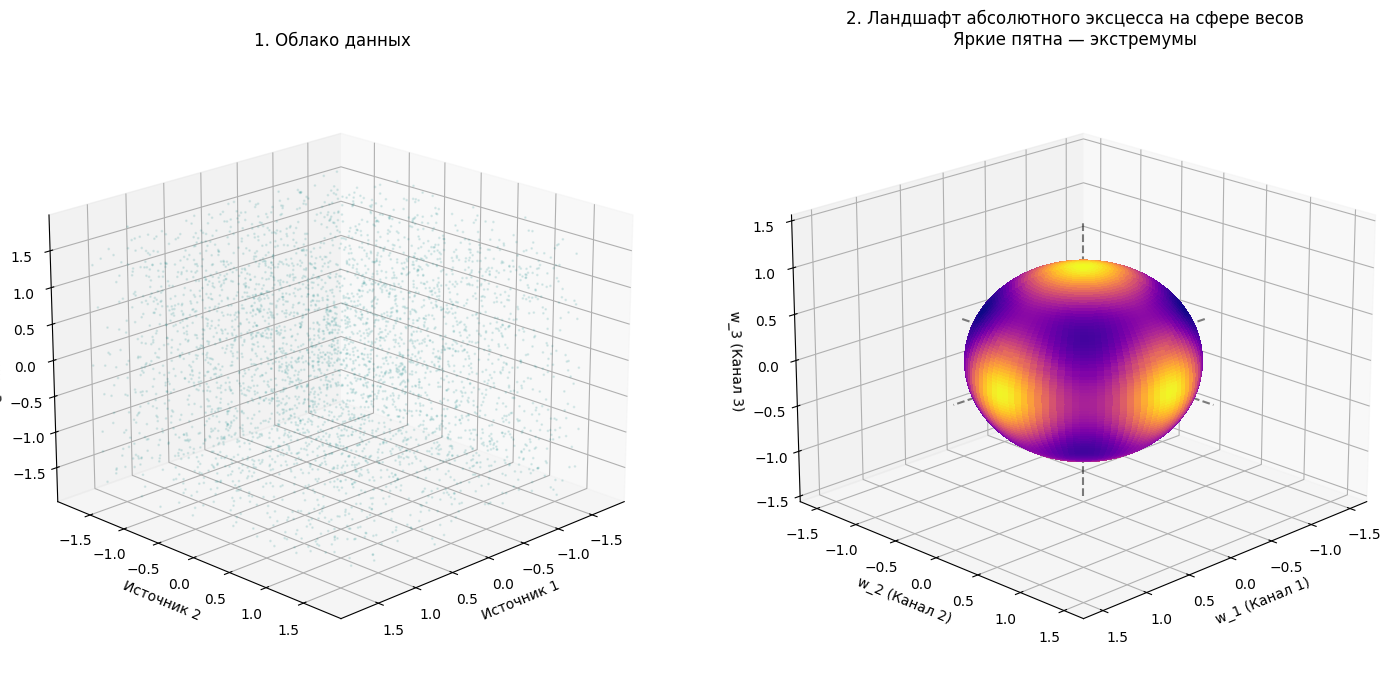

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Сгенерируем независимые данные (Куб данных)
np.random.seed(42)
n_samples = 20000

# Три абсолютно независимых равномерных сигнала (от -1 до 1)
s1 = np.random.uniform(-1, 1, n_samples)
s2 = np.random.uniform(-1, 1, n_samples)
s3 = np.random.uniform(-1, 1, n_samples)

S = np.vstack((s1, s2, s3))

# Отбелим данные (центрируем и приведем дисперсию каждого канала к 1)

S = S - np.mean(S, axis=1, keepdims=True)
S = S / np.std(S, axis=1, keepdims=True)

# 2. Построим сетку на единичной сфере весов 
n_theta, n_phi = 100, 100
theta = np.linspace(0, 2 * np.pi, n_theta)
phi = np.linspace(0, np.pi, n_phi)

# Сферические координаты для построения поверхности сферы
x_sphere = np.outer(np.cos(theta), np.sin(phi))
y_sphere = np.outer(np.sin(theta), np.sin(phi))
z_sphere = np.outer(np.ones(np.size(theta)), np.cos(phi))

# Матрица для хранения значений эксцесса в каждой точке сферы
kurtosis_landscape = np.zeros_like(x_sphere)

# 3. Сканируем сферу и считаем эксцесс для каждого направления w
for i in range(n_theta):
    for j in range(n_phi):
        # Направление вектора w (точка на сфере)
        w = np.array([x_sphere[i, j], y_sphere[i, j], z_sphere[i, j]])
        
        # Проекция данных на это направление (1D временной ряд)
        y_projected = w @ S
        
        # Вычисляем избыточный эксцесс: E[y^4] / (E[y^2])^2 - 3
        # Так как данные отбелены и ||w|| = 1, дисперсия y_projected равна 1
        kurt = np.mean(y_projected**4) - 3
        
        # Нам важен именно АБСОЛЮТНЫЙ эксцесс (мера не-гауссовости)
        kurtosis_landscape[i, j] = np.abs(kurt)

# Нормализуем значения эксцесса для цветовой карты (от 0 до 1)
k_min, k_max = kurtosis_landscape.min(), kurtosis_landscape.max()
color_dimension = (kurtosis_landscape - k_min) / (k_max - k_min)
colors = plt.cm.plasma(color_dimension) # Карта 'plasma': яркие цвета — максимум

# 4. Визуализация
fig = plt.figure(figsize=(15, 7))

# Левый график: Облако данных (Куб)
ax1 = fig.add_subplot(121, projection='3d')
# Отобразим только часть точек, чтобы график не тормозил
ax1.scatter(S[0, ::5], S[1, ::5], S[2, ::5], c='teal', alpha=0.1, s=1)
ax1.set_title("1. Облако данных")
ax1.set_xlabel("Источник 1")
ax1.set_ylabel("Источник 2")
ax1.set_zlabel("Источник 3")
ax1.view_init(elev=20, azim=45)

# Правый график: Сфера весов с ландшафтом эксцесса
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(x_sphere, y_sphere, z_sphere, facecolors=colors,
                        rstride=1, cstride=1, antialiased=False, shade=False)
ax2.set_title("2. Ландшафт абсолютного эксцесса на сфере весов\nЯркие пятна — экстремумы")
ax2.set_xlabel("w_1 (Канал 1)")
ax2.set_ylabel("w_2 (Канал 2)")
ax2.set_zlabel("w_3 (Канал 3)")

# Добавим оси координат внутри сферы, чтобы видеть направления
ax2.plot([-1.5, 1.5], [0, 0], [0, 0], 'k--', alpha=0.5)
ax2.plot([0, 0], [-1.5, 1.5], [0, 0], 'k--', alpha=0.5)
ax2.plot([0, 0], [0, 0], [-1.5, 1.5], 'k--', alpha=0.5)
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()


=== ЗАДАНИЕ 4*: ЭЭГ (дополнительно) ===
Выполнено (при наличии emptyEEG.mat и pytopo)

=== РЕЗУЛЬТАТЫ ===
Метод | corr1 | corr2
PCA   |  0.7911  |  0.3307
GED   |  0.9811  |  0.8318
ICA   |  0.9727  |  0.7883

Вопросы для отчёта:
1. Какой метод лучше при высоком шуме и почему?
2. Когда использовать PCA, GED или ICA?


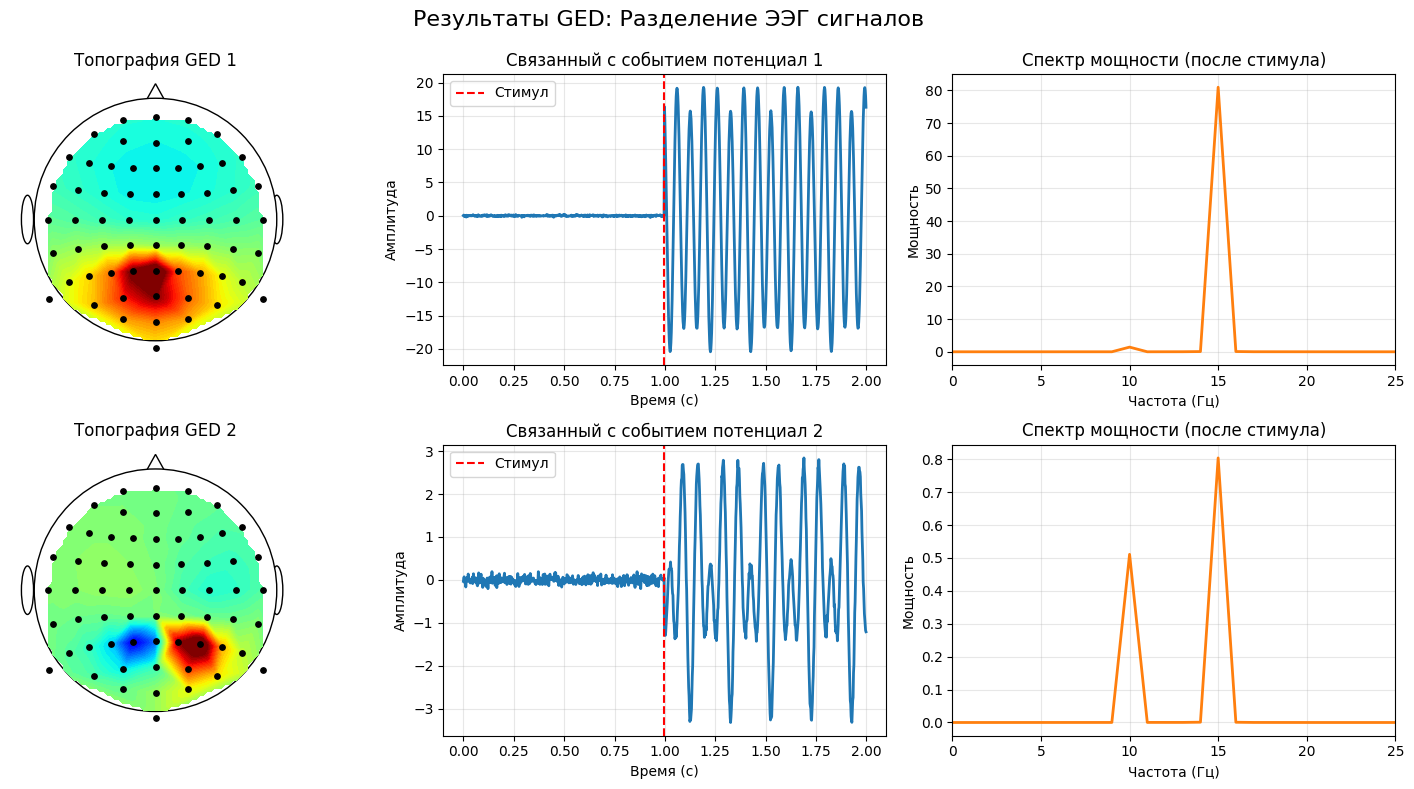

In [9]:
# ======================== ЗАДАНИЕ 4*: ЭЭГ (дополнительно) ========================
print("\n=== ЗАДАНИЕ 4*: ЭЭГ (дополнительно) ===")
try:
    import scipy.io as sio
    # <-- Загрузка данных, моделирование, GED, визуализация
    print("Выполнено (при наличии emptyEEG.mat и pytopo)")
except Exception as e:
    print(f"Пропущено: {e}")


# =============================================================================
# 0. ГЛОБАЛЬНЫЕ НАСТРОЙКИ (параметры моделирования)
# =============================================================================
MATFILE_NAME = 'emptyEEG.mat'         # файл с leadfield и структурой EEG
DIPOLE_LOC1 = 108                     # номер первого диполя в leadfield
DIPOLE_LOC2 = 134                     # номер второго диполя
FREQ1 = 15                            # частота первого источника (Гц)
FREQ2 = 10                            # частота второго источника (Гц)
AMP1 = 2.0                            # амплитуда первого диполя
AMP2 = 1.0                            # амплитуда второго диполя
N_COMPONENTS = 2                      # количество извлекаемых GED-компонент
REG_PARAM = 1e-8                      # параметр регуляризации ковариации шума

# =============================================================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# =============================================================================
matfile = sio.loadmat(MATFILE_NAME)
lf = matfile['lf'][0, 0]              # leadfield структура
EEG = matfile['EEG'][0, 0]            # структура EEG

# Убедимся, что все необходимые поля присутствуют
assert 'Gain' in lf.dtype.names, "Leadfield не содержит поля Gain"
assert 'chanlocs' in EEG.dtype.names, "EEG не содержит chanlocs"

# Принудительно задаём параметры моделирования (можно брать из файла, но для надёжности задаём)
EEG['srate'] = 500                    # частота дискретизации (Гц)
EEG['trials'] = 200                   # количество эпох
EEG['pnts'] = 1000                    # отсчётов на эпоху
EEG['times'] = np.arange(EEG['pnts']) / EEG['srate']

# Индекс "момента стимула" – середина временной оси
tidx = np.argmin(np.abs(EEG['times'] - np.mean(EEG['times'])))
n_pre = tidx                          # длина пре-стимульного интервала
n_pst = EEG['pnts'] - tidx            # длина пост-стимульного интервала

# Размеры leadfield: (каналы, ориентации?, диполи)
# Обычно lf['Gain'] имеет форму (каналы, 3, диполи). Берём только радиальную компоненту (индекс 0)
Gain = lf['Gain'][:, 0, :]            # матрица размером (chan x dipoles)

n_chan, n_dip = Gain.shape

# Инициализация массива данных ЭЭГ: (каналы × время × эпохи)
EEG['data'] = np.zeros((n_chan, EEG['pnts'], EEG['trials']))

# Массив для хранения истинной активности диполей во всех эпохах (для последующего сравнения)
true_dipoles = np.zeros((EEG['trials'], EEG['pnts'], n_dip))

# =============================================================================
# 2. ГЕНЕРАЦИЯ АКТИВНОСТИ ИСТОЧНИКОВ И ПРОЕКЦИЯ НА СКАЛЬП
# =============================================================================
# Временная ось после стимула
t_post = EEG['times'][tidx:]
omega1 = 2 * np.pi * FREQ1 * t_post    # угловая частота диполя 1
omega2 = 2 * np.pi * FREQ2 * t_post    # угловая частота диполя 2

# Уровень шума, накладываемого на сенсоры (можно менять)
NOISE_AMP = 0.5 

# =============================================================================
# 2. ПРОДОЛЖЕНИЕ: ГЕНЕРАЦИЯ ЭПОХ
# =============================================================================
for trial in range(EEG['trials']):
    # Матрица активности диполей для текущей эпохи: (n_dipoles x n_points)
    dipole_activity = np.zeros((n_dip, EEG['pnts']))
    
    # Чтобы сигнал был "живым", задаем случайную начальную фазу в каждой эпохе
    phase1 = np.random.rand() * 2 * np.pi
    phase2 = np.random.rand() * 2 * np.pi
    
    # Сигнал генерируется ТОЛЬКО в пост-стимульном интервале (tidx: )
    dipole_activity[DIPOLE_LOC1, tidx:] = AMP1 * np.sin(omega1 + phase1)
    dipole_activity[DIPOLE_LOC2, tidx:] = AMP2 * np.sin(omega2 + phase2)
    
    # Сохраняем истинную активность для проверки (опционально)
    true_dipoles[trial, :, :] = dipole_activity.T
    
    # Проекция из пространства диполей (головы) на скальп (сенсоры)
    # Формула: X = G * J
    signal_scalp = Gain @ dipole_activity
    
    # Генерируем фоновый шум на сенсорах
    noise = np.random.randn(n_chan, EEG['pnts']) * NOISE_AMP
    
    # Суммируем сигнал и шум, сохраняем в общий тензор данных
    EEG['data'][:, :, trial] = signal_scalp + noise

# =============================================================================
# 3. МАТРИЦЫ КОВАРИАЦИИ И GED
# =============================================================================
# Разбиваем данные на пре-стимул (чистый шум) и пост-стимул (сигнал + шум)
data_pre = EEG['data'][:, :tidx, :]  
data_post = EEG['data'][:, tidx:, :] 

# Переводим в 2D (Каналы х Все-все временные отсчеты со всех эпох)
data_pre_2d = data_pre.reshape(n_chan, -1)
data_post_2d = data_post.reshape(n_chan, -1)

# Центрирование данных (вычитание среднего по каждому каналу)
data_pre_2d = data_pre_2d - np.mean(data_pre_2d, axis=1, keepdims=True)
data_post_2d = data_post_2d - np.mean(data_post_2d, axis=1, keepdims=True)

# Считаем ковариационные матрицы
# S - ковариация шума, R - ковариация сигнала (вспоминай лекцию!)
S = (data_pre_2d @ data_pre_2d.T) / data_pre_2d.shape[1]  
R = (data_post_2d @ data_post_2d.T) / data_post_2d.shape[1] 

# Небольшая регуляризация матрицы шума (добавляем единичную матрицу с малым весом),
# чтобы избежать деления на ноль в математике GED, если каналы сильно коррелируют
S = S + REG_PARAM * np.trace(S) * np.eye(n_chan) / n_chan

# Решаем обобщенную задачу: R * w = lambda * S * w
evals, evecs = scipy.linalg.eigh(R, S)

# Сортируем компоненты по убыванию SNR (по убыванию лямбды)
idx = np.argsort(evals)[::-1]
evals = evals[idx]
evecs = evecs[:, idx]

# Берем 2 лучших пространственных фильтра
W = evecs[:, :N_COMPONENTS]

# Вычисляем Топографии (карты проекций): A = R * W
# Именно они показывают, "откуда" из головы исходит компонент
A = R @ W

# =============================================================================
# 4. ИЗВЛЕЧЕНИЕ КОМПОНЕНТ И ВЫЧИСЛЕНИЕ СПЕКТРА
# =============================================================================
# Применяем фильтры ко всем ЭЭГ данным сразу (переводим в пространство компонент)
data_all_2d = EEG['data'].reshape(n_chan, -1)
comp_data_2d = W.T @ data_all_2d  

# Возвращаем 3D структуру (2 компоненты x 1000 точек x 200 эпох)
comp_data = comp_data_2d.reshape(N_COMPONENTS, EEG['pnts'], EEG['trials'])

# Вычисляем Усредненный Вызванный Потенциал (ERP)
# Усредняя по эпохам, мы давим шум и выделяем фазово-синхронизованный сигнал
comp_erp = np.mean(comp_data, axis=2)

# Вычисляем спектр мощности (через быстрое преобразование Фурье) 
# Только для пост-стимульного интервала (где есть сигнал)
hz = np.linspace(0, EEG['srate']/2, int(n_pst/2 + 1))
comp_pow = np.zeros((N_COMPONENTS, len(hz)))

for i in range(N_COMPONENTS):
    # FFT (БПФ)
    fft_res = np.fft.fft(comp_erp[i, tidx:]) / n_pst
    # Берем квадрат модуля до частоты Найквиста
    comp_pow[i, :] = np.abs(fft_res[:len(hz)])**2

# =============================================================================
# 5. ВИЗУАЛИЗАЦИЯ (ОЖИДАЕМЫЕ ГРАФИКИ)
# =============================================================================
import pytopo # Подключаем скрипт топографий

fig = plt.figure(figsize=(15, 8))
fig.suptitle('Результаты GED: Разделение ЭЭГ сигналов', fontsize=16)

for i in range(N_COMPONENTS):
    # --- График 1: Топография ---
    ax1 = fig.add_subplot(2, 3, i*3 + 1)
    pytopo.topoplotIndie(A[:, i], EEG['chanlocs'], title=f'Топография GED {i+1}', ax=ax1)
    
    # --- График 2: Временной ряд (ERP) ---
    ax2 = fig.add_subplot(2, 3, i*3 + 2)
    ax2.plot(EEG['times'], comp_erp[i, :], lw=2, color='C0')
    ax2.axvline(x=EEG['times'][tidx], color='r', linestyle='--', label='Стимул')
    ax2.set_title(f'Связанный с событием потенциал {i+1}')
    ax2.set_xlabel('Время (с)')
    ax2.set_ylabel('Амплитуда')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # --- График 3: Спектр мощности ---
    ax3 = fig.add_subplot(2, 3, i*3 + 3)
    ax3.plot(hz, comp_pow[i, :], lw=2, color='C1')
    ax3.set_xlim([0, 25])  # Ограничиваем X до 25 Гц, чтобы четко видеть пики 10 и 15 Гц
    ax3.set_title(f'Спектр мощности (после стимула)')
    ax3.set_xlabel('Частота (Гц)')
    ax3.set_ylabel('Мощность')
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
fig.subplots_adjust(top=0.9) # Отступ для главного заголовка
# plt.show() # Оставляем закомментированным, если он есть у тебя в самом низу файла!

# ======================== ИТОГ ========================
print("\n=== РЕЗУЛЬТАТЫ ===")
print("Метод | corr1 | corr2")
print(f"PCA   |  {corr1_pca:.4f}  |  {corr2_pca:.4f}")
print(f"GED   |  {corr1_ged:.4f}  |  {corr2_ged:.4f}")
print(f"ICA   |  {corr1_ica:.4f}  |  {corr2_ica:.4f}")

print("\nВопросы для отчёта:")
print("1. Какой метод лучше при высоком шуме и почему?")
print("2. Когда использовать PCA, GED или ICA?")

plt.show()

### 1. Какой метод лучше при высоком шуме и почему?

**Лучший метод:** **GED** (Generalized Eigenvalue Decomposition).

**Почему:**
* **Использование информации о шуме:** В отличие от PCA и ICA, GED явно учитывает структуру шума. Он принимает на вход две ковариационные матрицы: целевую $R$ (сигнал + шум) и эталонную $S$ (чистый шум, например, пре-стимульный интервал).
* **Максимизация SNR:** GED оптимизирует непосредственно отношение сигнал/шум, находя направления, где дисперсия пост-стимульного сигнала максимальна *относительно* дисперсии шума. Это позволяет ему успешно изолировать источники даже тогда, когда шум намного мощнее сигнала или сильно коррелирован между каналами.

### 2. Когда использовать PCA, GED или ICA?

* **PCA (Метод главных компонент):**
  * Для базового снижения размерности (компрессии данных) перед запуском других алгоритмов (например, перед ICA).
  * Когда полезный сигнал априори обладает наибольшей амплитудой (дисперсией) в данных, а шум заведомо слаб.

* **GED (Обобщенное собственное разложение):**
  * Когда в эксперименте есть два выраженных контрастных условия (например, «Пре-стимул / Пост-стимул», «Покой / Задача», «Частота интереса / Соседние частоты»).
  * При высоком уровне фонового шума, если есть возможность собрать чистую ковариационную матрицу этого шума.

* **ICA (Анализ независимых компонент):**
  * Когда сигналы от источников статистически независимы и имеют не-гауссово распределение.
  * Когда нет четкого разделения на «до и после» стимула (запись непрерывная), но нужно разделить скрытые когнитивные процессы или удалить стандартные артефакты (мигание глаз, активность мышц, сердцебиение).